***

## Deep Learning & Generative AI - Exam Practice

## PRACTICAL 5 : Autoencoders

***

#### Objective: To implement an **Autoencoder** for learning compact latent representations and reconstructing handwritten digit images.

#### Theory Notes:

* **Autoencoder:** A neural network that learns to reproduce its input at the output.
* **Encoder:** Converts the input into a smaller latent representation.
* **Latent representation:** A compact set of learned features containing important information about the input.
* **Decoder:** Reconstructs the original input from the latent representation.
* **Reconstruction loss:** Measures the difference between the original and reconstructed input.
* **MSE (Mean Squared Error):** A common reconstruction loss for continuous pixel values.
* **Denoising:** An autoencoder can learn to reconstruct a clean image from a noisy input.
* In this practical, the **Digits dataset** is used, containing 8 × 8 grayscale handwritten digit images.

***

### 1] import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(42)

### 2] load the digits dataset

In [2]:
digits = load_digits()

X = digits.data
y = digits.target
images = digits.images

print('Number of samples:', X.shape[0])
print('Number of features:', X.shape[1])
print('Image size:', images.shape[1:])
print('Classes:', np.unique(y))

Number of samples: 1797
Number of features: 64
Image size: (8, 8)
Classes: [0 1 2 3 4 5 6 7 8 9]


### 3] visualize sample images

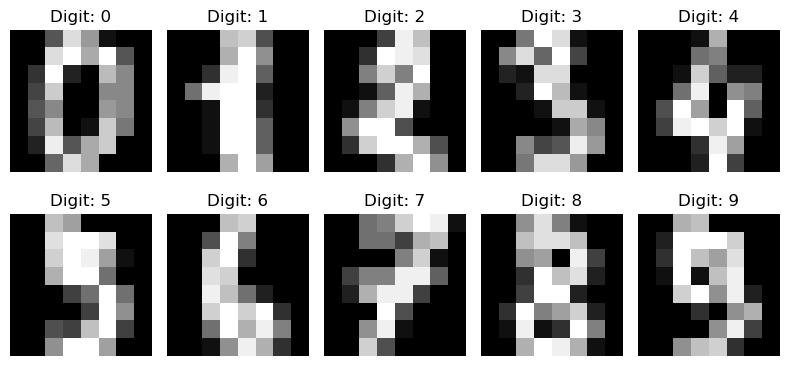

In [3]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f'Digit: {y[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 4] normalize the input

The original pixel values range from **0 to 16**. They are normalized to **0 to 1**.

In [4]:
X = X / 16.0

print('Minimum:', X.min())
print('Maximum:', X.max())

Minimum: 0.0
Maximum: 1.0


### 5] train test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y )

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Training shape: (1437, 64)
Testing shape: (360, 64)


### 6] construct the autoencoder

The model uses **32 latent features** to compress the original 64-pixel input.

**Architecture:** `64 input features → 32 latent features → 64 reconstructed features`

In [6]:
LATENT_DIMENSION = 32

autoencoder = MLPRegressor( hidden_layer_sizes=(LATENT_DIMENSION,), 
                           activation='logistic',
                           solver='adam', 
                           learning_rate_init=0.001,
                           batch_size=64,
                           max_iter=200,
                           early_stopping=True,
                           random_state=42 )

print('Input features:', X_train.shape[1])
print('Latent dimension:', LATENT_DIMENSION)
print('Output features:', X_train.shape[1])

Input features: 64
Latent dimension: 32
Output features: 64


### 7] train the autoencoder

The input and target are both `X_train`, because the autoencoder learns to reconstruct its own input.

In [7]:
autoencoder.fit(X_train, X_train)

print('Training completed.')
print('Iterations:', autoencoder.n_iter_)
print('Final loss:', autoencoder.loss_)

Training completed.
Iterations: 200
Final loss: 0.0023177392968605002


C:\Users\Shinde\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 8] plot training loss

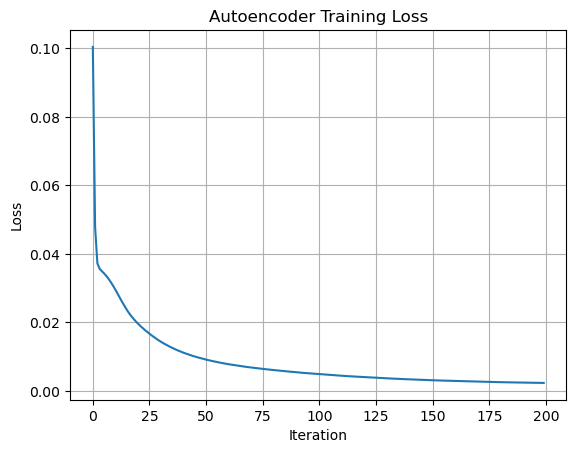

In [8]:
plt.plot(autoencoder.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.grid()
plt.show()

### 9] reconstruct test images

In [9]:
X_reconstructed = autoencoder.predict(X_test)
X_reconstructed = np.clip(X_reconstructed, 0, 1)

print('Original shape:', X_test.shape)
print('Reconstructed shape:', X_reconstructed.shape)

Original shape: (360, 64)
Reconstructed shape: (360, 64)


### 10] calculate reconstruction error

Mean Squared Error (MSE) measures the difference between original and reconstructed images.

In [10]:
mse = mean_squared_error(X_test, X_reconstructed)

print(f'Test Reconstruction MSE: {mse:.6f}')

Test Reconstruction MSE: 0.003894


### 11] compare original and reconstructed images

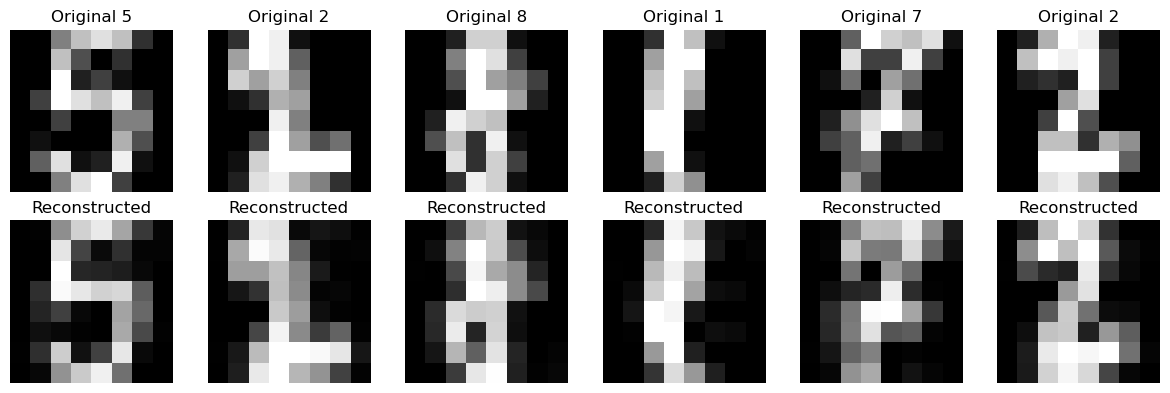

In [11]:
N = 6
plt.figure(figsize=(12, 4))

for i in range(N):
    plt.subplot(2, N, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f'Original {y_test[i]}')
    plt.axis('off')

    plt.subplot(2, N, N + i + 1)
    plt.imshow(X_reconstructed[i].reshape(8, 8), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 12] extract latent representation

The encoder converts each 64-dimensional image into a **32-dimensional latent vector**.

In [12]:
# Encoder weights and bias
weights = autoencoder.coefs_[0]
bias = autoencoder.intercepts_[0]

# Logistic activation used by the hidden layer
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

Z_test = sigmoid(X_test @ weights + bias)

print('Original shape:', X_test.shape)
print('Latent feature shape:', Z_test.shape)

Original shape: (360, 64)
Latent feature shape: (360, 32)


### 13] visualize latent features

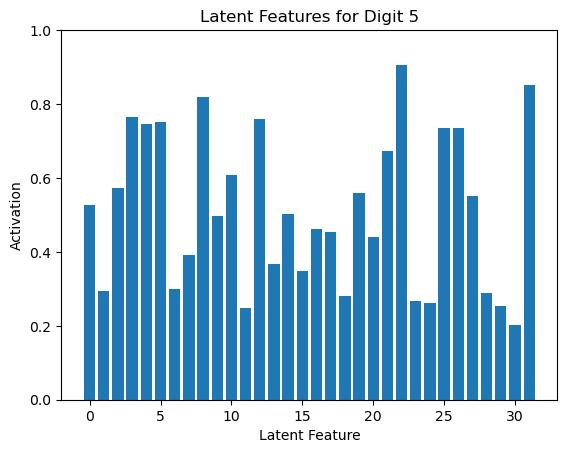

In [13]:
sample_index = 0

plt.bar(np.arange(LATENT_DIMENSION), Z_test[sample_index])
plt.xlabel('Latent Feature')
plt.ylabel('Activation')
plt.title(f'Latent Features for Digit {y_test[sample_index]}')
plt.ylim(0, 1)
plt.show()

### 14] denoising using the autoencoder

Noise is added to a test image and the trained autoencoder attempts to reconstruct a cleaner version.

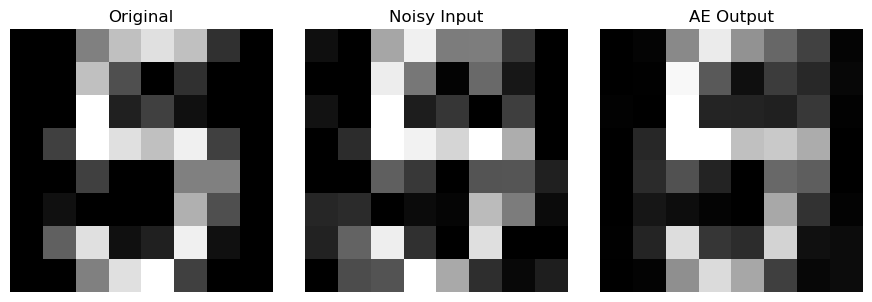

In [14]:
rng = np.random.default_rng(42)

sample = X_test[0]
noise = rng.normal(0, 0.20, size=sample.shape)
noisy_sample = np.clip(sample + noise, 0, 1)

denoised = autoencoder.predict(noisy_sample.reshape(1, -1))[0]
denoised = np.clip(denoised, 0, 1)

plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(sample.reshape(8, 8), cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy_sample.reshape(8, 8), cmap='gray')
plt.title('Noisy Input')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(denoised.reshape(8, 8), cmap='gray')
plt.title('AE Output')
plt.axis('off')

plt.tight_layout()
plt.show()

***

### quick revision:

* **Autoencoder:** Learns to reconstruct its input.
* **Encoder:** Compresses the input into a latent representation.
* **Latent space:** Compact representation of important features.
* **Decoder:** Reconstructs the original input.
* **Input:** 64 features for an 8 × 8 image.
* **Latent dimension:** 32 features.
* **Output:** 64 reconstructed features.
* **Loss:** Reconstruction loss / MSE.
* **Denoising:** Autoencoder can reconstruct a cleaner image from a noisy input.
* **Main objective:** Learn useful compact representations while minimizing reconstruction error.

***